# Indoor Navigation with a Smartphone, BLE Beacons, and IMU — Final Report

**Embedded Intelligence — partial exam assignment.**

We estimate the position and floor of a person walking through the two-floor EMI
building from a pocket smartphone, by fusing **step-based motion (PDR)**, **BLE
beacon signal strength**, and **building-structure knowledge** in a **particle
filter** (the single lecture method we use, chosen over the Kalman filter).

This notebook is the submission summary: it presents every required section and the
headline results, running the pipeline from `src/`. The detailed, cell-by-cell
derivations are in the companion notebooks **01–05**, and the three-source
related-work discussion is in **`Embedded_source_doc.ipynb`**.

In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

import preprocessing
import imu
import building
import ble
import evaluation
import particle_filter as pf
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

## 1. Experimental setup and data collection

The EMI building has two floors sharing one long main corridor, with eight installed
BLE beacons (six are heard in the data). We recorded **four measurement runs** with
the phone in a trouser pocket, each starting from a different position and crossing
between floors. At selected laboratory doors the person paused and we logged the
time **and the hand-counted step total** — these door timestamps are the ground
truth. Full protocol: `docs/experiment_protocol.md` and notebook **01**.

## 2. Experimental protocol (the four runs)

| Run | Objective | Floor transitions |
|-----|-----------|-------------------|
| 1 | Loop over both floors; speed-up on Level 1 | 1 up (east), 1 down (west) |
| 2 | Two-floor loop; return along Level 0 | 1 up (east), 1 down (west) |
| 3 | Two Level-0 traversals; one ascent, one descent | 1 up (west), 1 down (east) |
| 4 | Two Level-1 traversals; speed-up on Level 0 | 1 up (west), 1 down (west) |

## 3. Sensors and data sources

Each run is one CSV split by a `source` column: **IMU** (`accel` for steps, `gyro`
for heading, `mag` and `imu_processed` unused), **BLE** RSSI (`arrive_emi*`
beacons), plus a raw scan (dropped). `preprocessing.load_run` cleans these into a
`Run` object with a shared `t_rel` clock.

In [2]:
rows = []
for run_id in [1, 2, 3, 4]:
    r = preprocessing.load_run(run_id, raw_dir=RAW)
    rows.append({"run": run_id, "duration_s": round(r.duration_s, 1),
                 "accel_samples": r.meta["imu_counts"]["accel"],
                 "ble_readings": r.meta["ble_clean_rows"],
                 "beacons_seen": len(r.meta["beacons_seen"])})
pd.DataFrame(rows)

,run,duration_s,accel_samples,ble_readings,beacons_seen
0,1,158.9,15965,2151,6
1,2,174.9,17576,2181,6
2,3,248.1,24927,3185,6
3,4,206.4,20738,2765,6


## 4. Preprocessing and synchronisation

`load_run` splits the streams, cleans them, and gives them one shared time origin
(`t_rel`). Motion and BLE are kept **separate on a shared clock** (not merged): the
filter predicts on each step and only corrects when a BLE reading arrives
(event-driven). Detail: notebook **02**.

## 5. Step detection and the motion model

Steps are peaks in the acceleration magnitude (orientation-independent), with an
adaptive threshold calibrated so the count matches the hand-counted totals. The step
length is a measured **0.65 m**; heading comes from the gyroscope (projected on
gravity, bias-removed) since the magnetometer is unreliable indoors. Detail:
notebook **03**.

In [3]:
rows = []
for run_id in [1, 2, 3, 4]:
    r = preprocessing.load_run(run_id, raw_dir=RAW)
    detected = len(imu.detect_steps(r.accel))
    counted = int(evaluation.load_reference(run_id, reference_file=REF).iloc[-1]["sum_steps"])
    rows.append({"run": run_id, "detected": detected, "counted": counted,
                 "error_%": round(100 * (detected - counted) / counted, 1)})
pd.DataFrame(rows)

,run,detected,counted,error_%
0,1,214,216,-0.9
1,2,231,238,-2.9
2,3,335,340,-1.5
3,4,281,282,-0.4


## 6. Use and weighting of BLE beacon signals

Each RSSI reading weights a particle by how well its position explains it, via a
**log-distance path-loss likelihood** — strong readings are weighted more (they only
fit particles close to the beacon). The path-loss parameters were **calibrated to
the reference distances** (the real corridor path loss is much flatter than free
space). Detail: notebook **04**.

## 7. Integration of structural knowledge (the building)

Each floor is a corridor centre-line with a half-width (walkable if within it); the
metric scale (~5.25 m door spacing) is derived from the counted steps. Doors and the
six beacons are placed on the corridor, and floor changes are allowed only inside
the two staircase zones. Detail: notebook **04**.

## 8. Modelling and implementation of the particle filter

The filter keeps a cloud of particles `(x, y, floor)`. Each step it **predicts**
(move by the motion sector), **constrains** (down-weight off-corridor particles),
**updates** (multiply in the BLE likelihood), **resamples** when the effective
sample size drops, and may **change floor** at a staircase. It was built and
validated in four sub-steps (5a motion → 5b +map → 5c +BLE → 5d +floors).

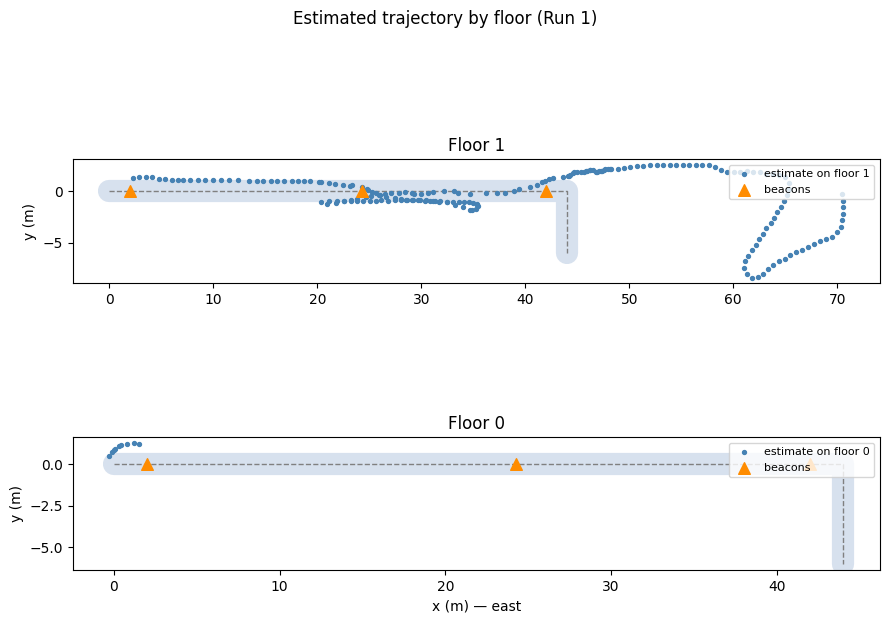

In [4]:
run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
trajectory, spread, n_resamples = pf.run_filter(
    run, motion, start=cfg["start"], floor=cfg["floor"],
    building=building, ble=ble, seed=0)

viz.plot_trajectory_two_floors(trajectory, building.corridor_polyline(0),
                               building.CORRIDOR_HALF_WIDTH_M,
                               beacons=building.beacon_positions(), run_id=1)
plt.show()

## 9. Experimental design and evaluation methodology

We evaluate against the door references: at each checkpoint we measure the
**position error** (estimate interpolated to the checkpoint time vs the true door)
and the **floor accuracy**. We also run an **ablation** — map-only vs +BLE vs full —
to isolate each fusion component. Detail: notebook **05**.

## 10. Results and evaluation

In [5]:
# Full-filter metrics per run.
rows = []
for run_id in [1, 2, 3, 4]:
    r = preprocessing.load_run(run_id, raw_dir=RAW)
    c = preprocessing.RUN_START[run_id]
    m = imu.build_motion_table(r, initial_heading=c["initial_heading"])
    traj = pf.run_filter(r, m, start=c["start"], floor=c["floor"], building=building, ble=ble, seed=0)[0]
    metrics = evaluation.summary_metrics(
        evaluation.error_at_references(traj, evaluation.load_reference(run_id, reference_file=REF)))
    metrics["run"] = run_id
    rows.append(metrics)
pd.DataFrame(rows)[["run", "mean_error_m", "median_error_m", "floor_accuracy", "n_checkpoints"]]

,run,mean_error_m,median_error_m,floor_accuracy,n_checkpoints
0,1,14.45,4.44,0.53,15
1,2,29.27,25.96,0.47,15
2,3,17.53,18.06,0.68,22
3,4,19.76,16.83,0.70,23


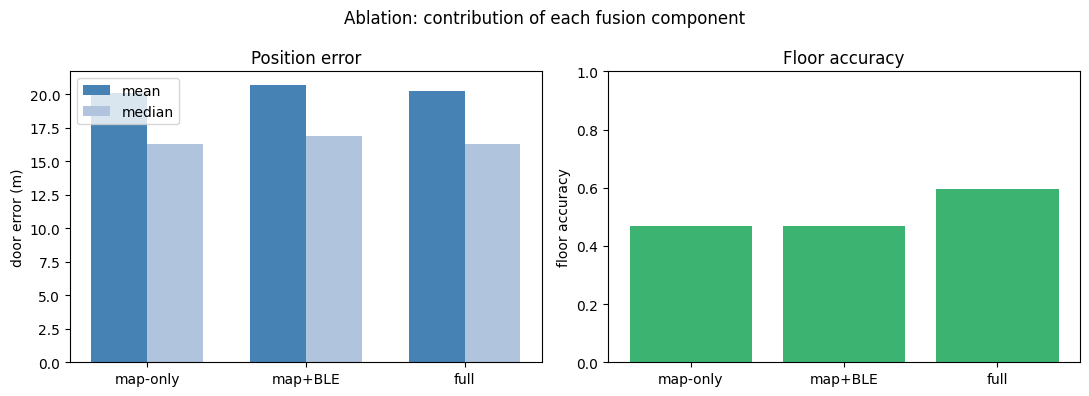

In [6]:
# Ablation across all runs.
def variants(run_id):
    r = preprocessing.load_run(run_id, raw_dir=RAW)
    c = preprocessing.RUN_START[run_id]
    m = imu.build_motion_table(r, initial_heading=c["initial_heading"])
    t_map = pf.run_with_constraints(r, m, start=c["start"], building=building, floor=0, seed=0)[0]
    t_ble = pf.run_with_ble(r, m, start=c["start"], building=building, ble=ble, floor=0, seed=0)[0]
    t_full = pf.run_filter(r, m, start=c["start"], floor=c["floor"], building=building, ble=ble, seed=0)[0]
    return evaluation.compare_metrics({"map-only": t_map, "map+BLE": t_ble, "full": t_full},
                                      evaluation.load_reference(run_id, reference_file=REF))

ablation = pd.concat([variants(r) for r in [1, 2, 3, 4]]).groupby("variant", sort=False).mean(numeric_only=True).reset_index()
viz.plot_ablation(ablation)
plt.show()

The estimate is accurate on well-tracked corridor segments (median error a few
metres) but the **mean** is inflated by the floor-1 drift. The ablation shows **floor
handling is the decisive contribution to floor accuracy** (~0.47 → ~0.60 overall,
Run 4: 0.30 → 0.70), while BLE is roughly neutral on position and the map provides
the base constraint.

## 11. Discussion of error sources, limitations, and improvements

- **Heading drift** (gyro integration) is the main position error source; the map
  and BLE damp but do not fully remove it.
- **BLE is coarse indoors** — the flat calibrated path loss means RSSI constrains
  position only loosely.
- **Floor determination is imperfect** — runs starting at a staircase can flip floor
  early, and position drift can leave the cloud short of a staircase.
- **Improvements:** a multiplicative wrong-floor penalty in the BLE likelihood
  (stronger floor discrimination), a per-run/adaptive step length, and denser or
  better-calibrated beacons. A perfect system is not expected; the value is a sound,
  honestly-evaluated method.

## 12. Related work

We position our approach against three sources (full discussion in
`Embedded_source_doc.ipynb`):

1. **Leitch et al. (2023)** — a survey of indoor localization (WiFi/BLE/UWB/IMU);
   supports our choice of BLE + IMU.
2. **Jin et al. (2023)** — BLE + PDR fused in a particle filter, the method closest
   to ours; our work *extends* it with map constraints, two floors, and a
   pocket-placed phone (their stated future work).
3. **Chen et al. (2016)** — EKF vs particle filter vs MAP for IMU/ToA positioning;
   supports our choice of the particle filter over the Kalman filter.